# S8: почему гармонический источник не подтверждает трек

**Диагностика, а не настройка алгоритмов.** Пять заранее выбранных пар сохранённых
spatial harmonic/broadband запусков, 40 исторических треков и четыре разрешённых
идеальных replay. Протокол заморожен коммитом `3bbf527` от базы
`ae2858718bd00a318512d996589d91ade7c9a578`.

У harmonic 200 м построены допустимые гипотезы, но независимые измерения их не
подтвердили; в 700 м допустимая гипотеза вообще не построена. Все четыре
`ideal_bearing_zero_bias_same_R` подтвердились в 1,055 с и потребовали два fits.
Калибровочный bias мал по сравнению с наблюдаемыми ошибками; прежняя R не описывает
гармонические остатки. При этом идеальный replay одновременно убирает bearing
ошибку и bias, а потому не разделяет эти механизмы сам по себе.

Следующая одна проверяемая модификация: **явное отклонение неоднозначных bearing
кадров по сигналу и наблюдаемой структуре оценивания**, с независимыми development
и evaluation записями/seed. Рабочий frontend и tracker сейчас не изменялись.

## Контекст и метод

Исходные файлы и их SHA перечислены в `HARMONIC_TRACKING_FAILURE_PROTOCOL_MANIFEST.json`.
Производные таблицы находятся в `results/harmonic_tracking_failure`. Полные ответы и
ссылки на источники: `HARMONIC_TRACKING_FAILURE_REPORT.md`.

### Допущения

ENU, метры, секунды, $c=343$ м/с. Для каждой станции отдельно решается
$t_r=t_e+\|q(t_e)-p_k\|/c$. Истина находится только в оценке ошибок/диагностическом
входе. Остаток — сферический log-map в **prediction tangent basis** рабочего трекера:
$e=B(u)\operatorname{Log}_u(\hat u)$, затем $e_c=e-b$.

$d_R^2=e_c^T R^{-1}e_c$ — нормированный остаток bearing. Он отличается от innovation
NIS с $S=HPH^T+R$. Кадры, станции одной записи, повторные дальности и source/noise
пары зависимы; показанные квантили и корреляции являются описательными.
P95 использует линейную интерполяцию. Отбор для трекера: `frame_index % 32 == 0`;
для accuracy сохранены также все кадры.

In [1]:
from pathlib import Path
import sys, os, tempfile, json
ROOT = Path.cwd()
if not (ROOT / 'analysis').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'uav_harmonic_mpl'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from analysis.harmonic_tracking_failure import verify, DEFAULT_OUTPUT
from analysis.harmonic_failure_figures import (bearing_comparison, calibration_qq,
    error_consistency, failure_timeline)
from validation.gazebo_experiment import sha256
assert verify(DEFAULT_OUTPUT)['historical_inputs_unchanged']
OUT = DEFAULT_OUTPUT
FIGURES = OUT / 'figures'
FIGURES.mkdir(exist_ok=True)
print('SHA исходных и производных файлов проверены; новые вычисления фронтенда/трекера не запускаются.')

SHA исходных и производных файлов проверены; новые вычисления фронтенда/трекера не запускаются.


## Данные: пять фиксированных пар

Различаются source class и source seed. Физическое движение, геометрия,
реализация добавленного шума и расписание совпадают точно. Отбор по результату
отсутствует; исходная остановленная матрица остаётся неполной.

In [2]:
pairs = pd.read_json(OUT / 'pair_audit.json')
assert pairs.matching_trajectory_geometry_noise_schedule.all()
assert pairs.event_ids_disjoint.all()
display(pairs[['broadband_index', 'harmonic_index', 'distance_m', 'replicate', 'row_count_each',
               'matching_trajectory_geometry_noise_schedule']])
bearing = pd.read_csv(OUT / 'bearing_metrics.csv.gz')
calibration = pd.read_csv(OUT / 'calibration_metrics.csv.gz')
residuals = pd.read_csv(OUT / 'bearing_residuals.csv.gz')
chain = pd.read_csv(OUT / 'chain_summary.csv.gz')
hypotheses = pd.read_csv(OUT / 'hypothesis_details.csv.gz')
timeline = pd.read_csv(OUT / 'failure_timeline_200m.csv.gz')
assert len(chain) == 40 and len(bearing) == len(calibration) == 120
print('Реконструировано валидных angular residuals:', len(residuals))

,broadband_index,harmonic_index,distance_m,replicate,row_count_each,matching_trajectory_geometry_noise_schedule
0,0,6,200,0,11250,True
1,1,7,200,1,11250,True
2,2,8,700,0,11250,True
3,3,9,700,1,11250,True
4,4,10,1000,0,11250,True


Реконструировано валидных angular residuals: 112500


## Результаты: ухудшение направлений

Каждая точка — P95 одной станции одной последовательности. Сравнение двух строк
показывает, что ошибки есть и во всех кадрах, и после заранее заданного stride.
Логарифмическая шкала подписана явно. Валидность frontend не означает малую ошибку.

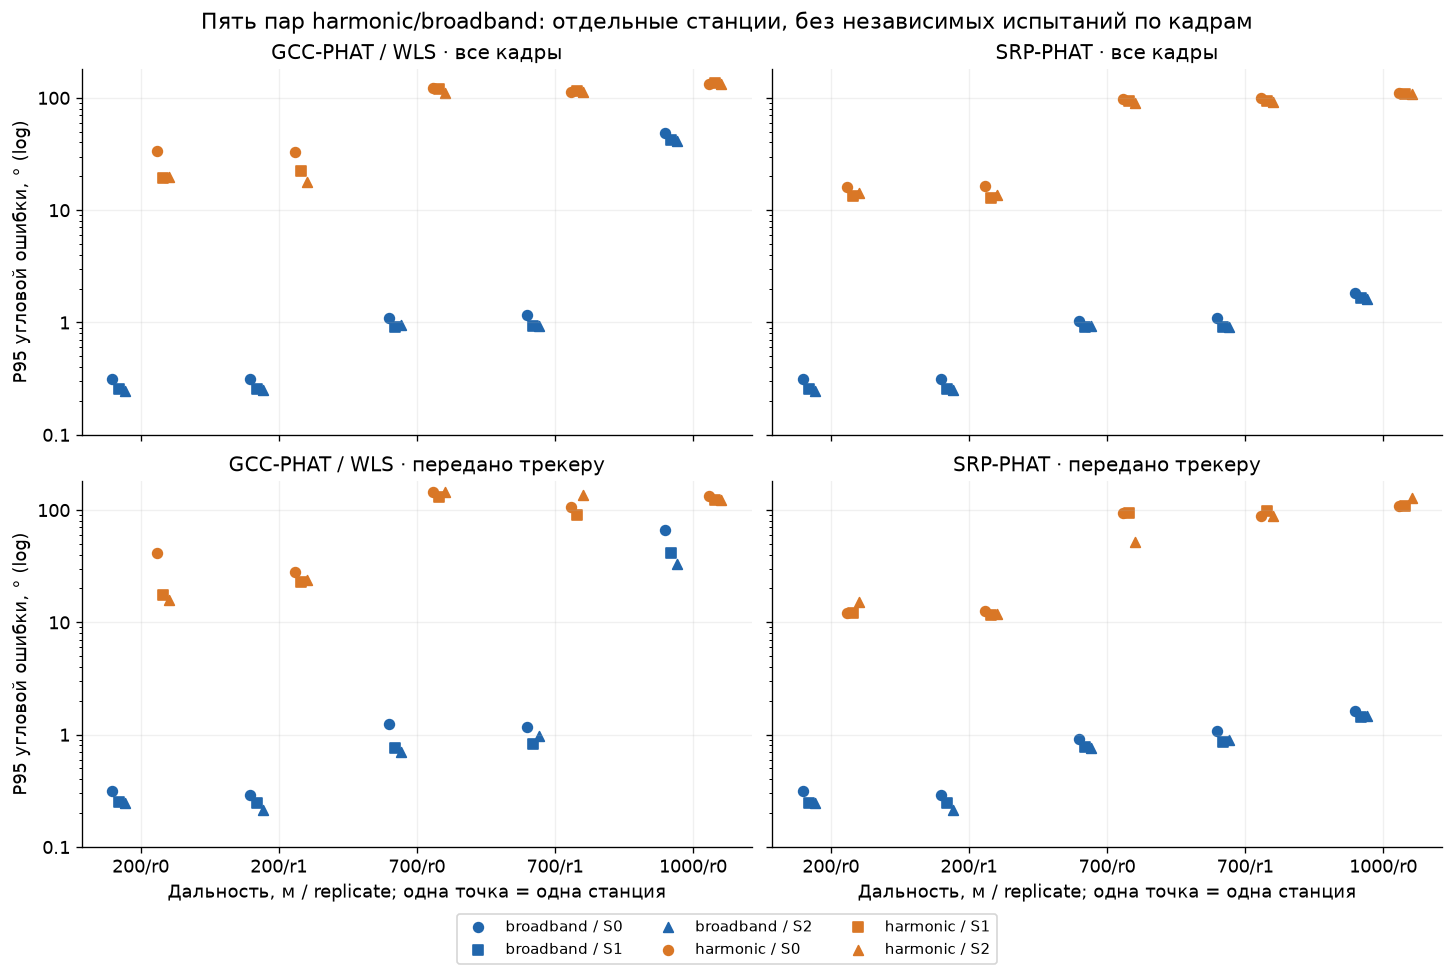

median_error_deg  p95_error_deg  \
index method                                                   
0     all_6_equal_gcc_wls               0.127          0.250   
      equal_weight_srp_phat             0.123          0.246   
1     all_6_equal_gcc_wls               0.112          0.247   
      equal_weight_srp_phat             0.112          0.247   
2     all_6_equal_gcc_wls               0.432          0.761   
      equal_weight_srp_phat             0.423          0.784   
3     all_6_equal_gcc_wls               0.392          0.969   
      equal_weight_srp_phat             0.393          0.904   
4     all_6_equal_gcc_wls               1.390         41.293   
      equal_weight_srp_phat             0.697          1.462   
6     all_6_equal_gcc_wls               5.654         17.494   
      equal_weight_srp_phat             6.446         12.003   
7     all_6_equal_gcc_wls               5.201         23.649   
      equal_weight_srp_phat             6.020         11.778   
8     all_6_equal_gcc_wls              26.025        144.566   
      equal_weight_srp_phat            11.105         93.285   
9     all_6_equal_gcc_wls              28.820        106.460   
      equal_weight_srp_phat            12.286         88.290   
10    all_6_equal_gcc_wls              38.421        122.941   
      equal_weight_srp_phat            20.027        109.106   

                             fraction_valid_over_10deg  
index method                                            
0     all_6_equal_gcc_wls                        0.000  
      equal_weight_srp_phat                      0.000  
1     all_6_equal_gcc_wls                        0.000  
      equal_weight_srp_phat                      0.000  
2     all_6_equal_gcc_wls                        0.000  
      equal_weight_srp_phat                      0.000  
3     all_6_equal_gcc_wls                        0.000  
      equal_weight_srp_phat                      0.000  
4     all_6_equal_gcc_wls                        0.339  
      equal_weight_srp_phat                      0.000  
6     all_6_equal_gcc_wls                        0.169  
      equal_weight_srp_phat                      0.153  
7     all_6_equal_gcc_wls                        0.136  
      equal_weight_srp_phat                      0.153  
8     all_6_equal_gcc_wls                        0.814  
      equal_weight_srp_phat                      0.542  
9     all_6_equal_gcc_wls                        0.864  
      equal_weight_srp_phat                      0.610  
10    all_6_equal_gcc_wls                        0.966  
      equal_weight_srp_phat                      0.729

Frontend valid fraction, min/max: 1.0 1.0


In [3]:
fig = bearing_comparison(bearing)
fig.savefig(FIGURES / 'bearing_comparison.png', bbox_inches='tight')
plt.show()
selected = bearing[bearing['subset'] == 'tracker_selected']
display(selected.groupby(['index', 'method'])[['median_error_deg', 'p95_error_deg',
         'fraction_valid_over_10deg']].median().round(3))
print('Frontend valid fraction, min/max:', bearing.valid_fraction.min(), bearing.valid_fraction.max())

## Применимость прежней калибровки

Таблица содержит медианы **станционных показателей**, а не ковариацию общего
независимого набора. Q–Q сравнивает эмпирические квантили $d_R^2$ с номинальной
центральной $\chi^2_2$. Это описательная проверка формы и масштаба, не iid p-value.
У broadband калибровка тоже ухудшается с расстоянием; harmonic mismatch намного
больше. Эмпирические параметры не передаются трекеру.

d_R2_median_after  \
distance_m source_class           method                                     
200        broadband              all_6_equal_gcc_wls              0.26537   
                                  equal_weight_srp_phat            0.25059   
           nonstationary_harmonic all_6_equal_gcc_wls            507.09842   
                                  equal_weight_srp_phat          667.28183   
700        broadband              all_6_equal_gcc_wls              2.94904   
                                  equal_weight_srp_phat            3.00873   
           nonstationary_harmonic all_6_equal_gcc_wls          13151.33454   
                                  equal_weight_srp_phat         2213.77531   
1000       broadband              all_6_equal_gcc_wls             35.19183   
                                  equal_weight_srp_phat            8.66267   
           nonstationary_harmonic all_6_equal_gcc_wls          25499.45977   
                                  equal_weight_srp_phat         7127.31759   

                                                         fraction_inside_nominal_chi2_95  \
distance_m source_class           method                                                   
200        broadband              all_6_equal_gcc_wls                            1.00000   
                                  equal_weight_srp_phat                          1.00000   
           nonstationary_harmonic all_6_equal_gcc_wls                            0.01695   
                                  equal_weight_srp_phat                          0.00847   
700        broadband              all_6_equal_gcc_wls                            0.77119   
                                  equal_weight_srp_phat                          0.79661   
           nonstationary_harmonic all_6_equal_gcc_wls                            0.00000   
                                  equal_weight_srp_phat                          0.00000   
1000       broadband              all_6_equal_gcc_wls                            0.25424   
                                  equal_weight_srp_phat                          0.40678   
           nonstationary_harmonic all_6_equal_gcc_wls                            0.00000   
                                  equal_weight_srp_phat                          0.00000   

                                                         empirical_mean_after_norm_deg  \
distance_m source_class           method                                                 
200        broadband              all_6_equal_gcc_wls                          0.01485   
                                  equal_weight_srp_phat                        0.01407   
           nonstationary_harmonic all_6_equal_gcc_wls                          1.86102   
                                  equal_weight_srp_phat                        1.03346   
700        broadband              all_6_equal_gcc_wls                          0.05556   
                                  equal_weight_srp_phat                        0.04743   
           nonstationary_harmonic all_6_equal_gcc_wls                         16.19044   
                                  equal_weight_srp_phat                       10.28980   
1000       broadband              all_6_equal_gcc_wls                          4.19658   
                                  equal_weight_srp_phat                        0.09987   
           nonstationary_harmonic all_6_equal_gcc_wls                         22.68117   
                                  equal_weight_srp_phat                       23.96107   

                                                         bias_norm_deg  
distance_m source_class           method                                
200        broadband              all_6_equal_gcc_wls          0.00949  
                                  equal_weight_srp_phat        0.00952  
           nonstationary_harmonic all_6_equal_gcc_wls          0.00949  
                                  equal_weight_sr

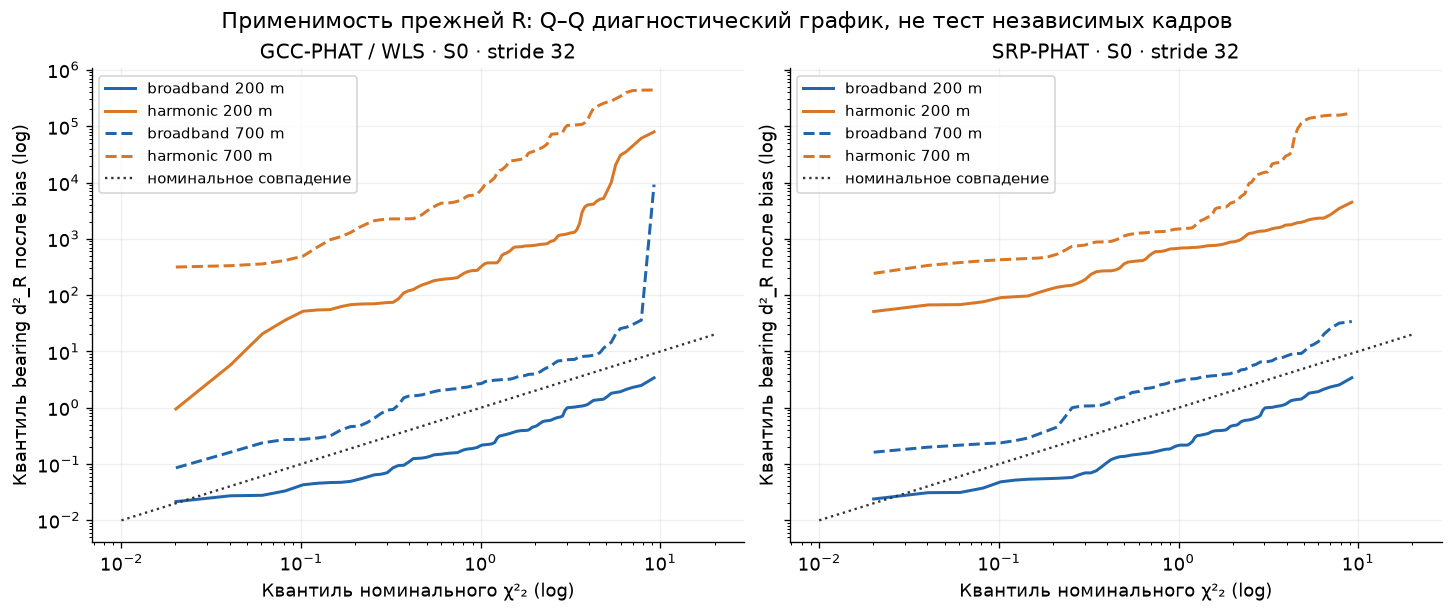

In [4]:
c = calibration[calibration['subset'] == 'tracker_selected']
display(c.groupby(['distance_m', 'source_class', 'method'])[
    ['d_R2_median_after', 'fraction_inside_nominal_chi2_95',
     'empirical_mean_after_norm_deg', 'bias_norm_deg']].median().round(5))
fig = calibration_qq(residuals)
fig.savefig(FIGURES / 'calibration_qq.png', bbox_inches='tight')
plt.show()

### Независимая проверка соглашения остатка на одном событии

Сравниваем сферический остаток, сохранённые компоненты, знак компенсации bias и
$d_R^2$. Здесь нет innovation covariance S и нет повторного обучения R.

In [5]:
from analysis import unseen_manoeuvres_and_sources as study
from analysis.localization_error_attribution import _measurement_rows
from model.bearing_statistics import tangent_residual
manifest = study._load(study.DEFAULT_OUTPUT)
source = study._directory(study.DEFAULT_OUTPUT, manifest['specs'][6])
row = _measurement_rows(source / 'bearing_records.csv.gz')[0]
config = next(c for c in manifest['processing']['calibration']['values']
              if c['station_id'] == row['station_id'] and c['estimator_variant'] == row['estimator_variant'])
e = tangent_residual(row['truth_local'], row['estimate_local'])
np.testing.assert_allclose(e, [row['residual_az_arc_rad'], row['residual_el_arc_rad']], atol=1e-11)
ec = e - np.array(config['bias_rad'])
dr2 = float(ec @ np.linalg.solve(np.array(config['covariance_rad2']), ec))
saved = residuals[residuals.event_id == row['event_id']].iloc[0]
assert np.isclose(dr2, saved.d_R2, rtol=1e-10)
print({'event_id': row['event_id'], 'angular_error_deg': float(np.rad2deg(np.linalg.norm(e))),
       'raw_residual_rad': e.tolist(), 'bias_corrected_rad': ec.tolist(), 'bearing_d_R2': dr2})

{'event_id': 'unseen-beffd269c4dc99056f925c98|S0|0|all_6_equal_gcc_wls', 'angular_error_deg': 6.671707661567293, 'raw_residual_rad': [0.1065422685799954, -0.04698700957325722], 'bias_corrected_rad': [0.10648060570016035, -0.047135229177436525], 'bearing_d_R2': 749.9227617797725}


## Структура ошибок во времени и между станциями

Серии крупных ошибок и корреляции сохранены по каждой станции/методу, отдельно
для обоих наборов кадров. Продолжительность серии равна n × шаг сетки; невалидный
или пропущенный кадр разрывает её. На выбранной сетке трекера шаг 0,341333 с.

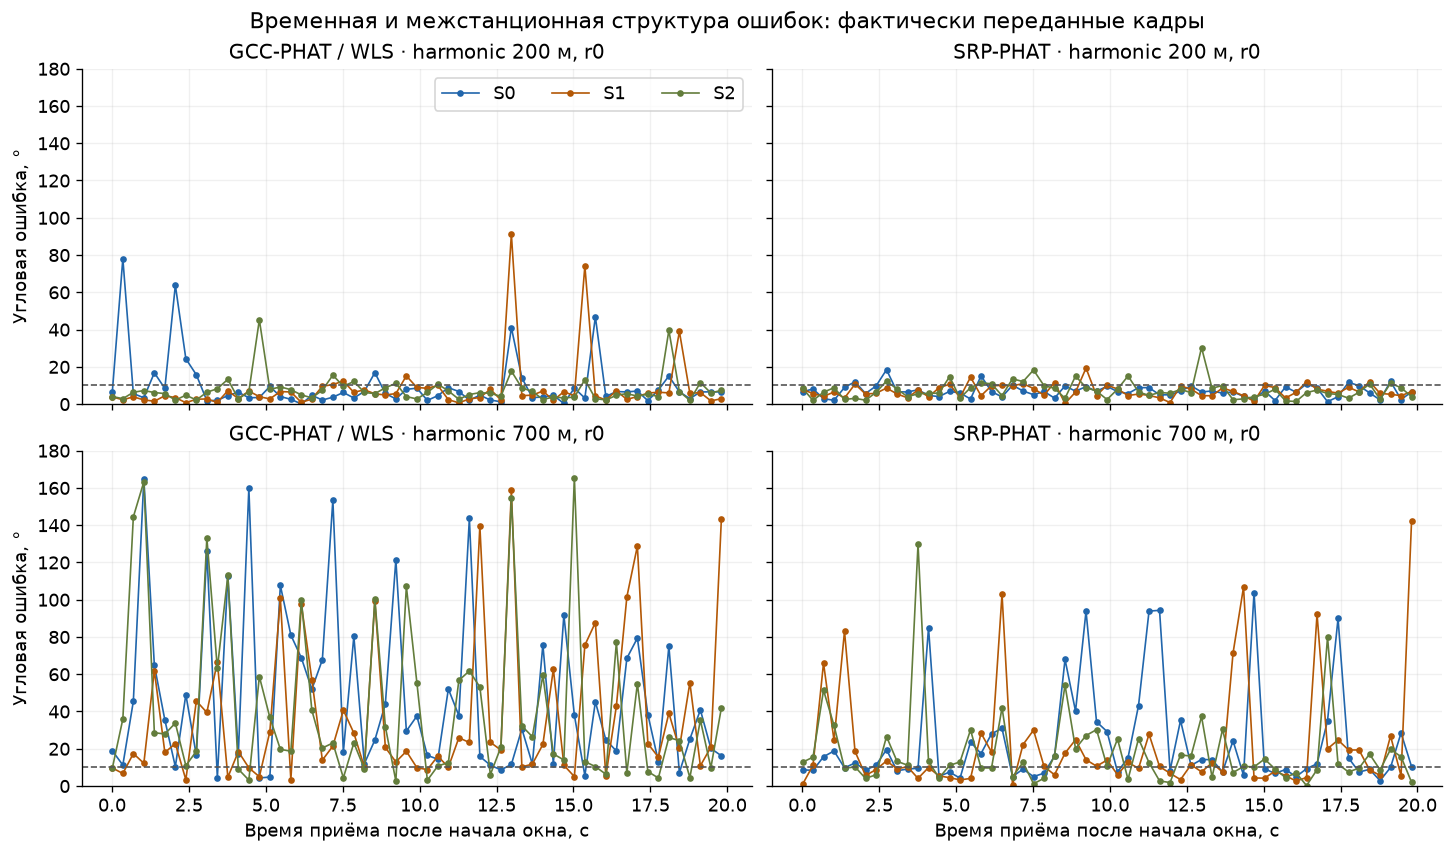

source_class            subset            method               
broadband               all_frames        all_6_equal_gcc_wls      0.079
                                          equal_weight_srp_phat    0.117
                        tracker_selected  all_6_equal_gcc_wls     -0.025
                                          equal_weight_srp_phat   -0.057
nonstationary_harmonic  all_frames        all_6_equal_gcc_wls      0.150
                                          equal_weight_srp_phat    0.199
                        tracker_selected  all_6_equal_gcc_wls      0.017
                                          equal_weight_srp_phat    0.023
Name: correlation, dtype: float64

angular_error_correlation  \
source_class           method                                             
broadband              all_6_equal_gcc_wls                        0.018   
                       equal_weight_srp_phat                      0.024   
nonstationary_harmonic all_6_equal_gcc_wls                        0.139   
                       equal_weight_srp_phat                      0.033   

                                              joint_over_10deg_fraction  
source_class           method                                            
broadband              all_6_equal_gcc_wls                        0.000  
                       equal_weight_srp_phat                      0.000  
nonstationary_harmonic all_6_equal_gcc_wls                        0.661  
                       equal_weight_srp_phat                      0.322

In [6]:
fig = error_consistency(residuals)
fig.savefig(FIGURES / 'error_consistency.png', bbox_inches='tight')
plt.show()
temporal = pd.read_csv(OUT / 'temporal_correlations.csv.gz')
interstation = pd.read_csv(OUT / 'interstation_correlations.csv.gz')
display(temporal[(temporal.component == 'error_deg_checked') & (temporal.lag_frames == 1)]
        .groupby(['source_class', 'subset', 'method']).correlation.median().round(3))
display(interstation[interstation['subset'] == 'tracker_selected']
        .groupby(['source_class', 'method'])[['angular_error_correlation',
             'joint_over_10deg_fraction']].median().round(3))

## Цепочка отказа: 200 м, replicate 0

Во всех четырёх исторических вариантах harmonic нет подтверждённого трека.
У GCC восемь созданных гипотез и 112 fits: предел гипотез, не предел fits.
У SRP семь гипотез, 128 выполненных fits и одна отклонённая до оптимизации
попытка. Состав измерений не теряется: доступны те же 177 событий трёх станций.
Точная последняя predictive S оценка первой GCC гипотезы принимает 2/22 будущих
измерений от одной станции; для подтверждения этого недостаточно.

,index,method,confirmation_variant,available_event_count,created_hypothesis_count,executed_optimizations,valid_publication_count,first_confirmation_s,hypothesis_limit_observed
0,0,all_6_equal_gcc_wls,baseline,177,1,2,168,1.055313,False
1,0,all_6_equal_gcc_wls,three_station_confirmation,177,1,2,168,1.055313,False
2,0,equal_weight_srp_phat,baseline,177,1,2,168,1.055313,False
3,0,equal_weight_srp_phat,three_station_confirmation,177,1,2,168,1.055313,False
20,6,all_6_equal_gcc_wls,baseline,177,8,112,0,NaN,True
21,6,all_6_equal_gcc_wls,three_station_confirmation,177,8,112,0,NaN,True
22,6,equal_weight_srp_phat,baseline,177,7,128,0,NaN,False
23,6,equal_weight_srp_phat,three_station_confirmation,177,7,128,0,NaN,False


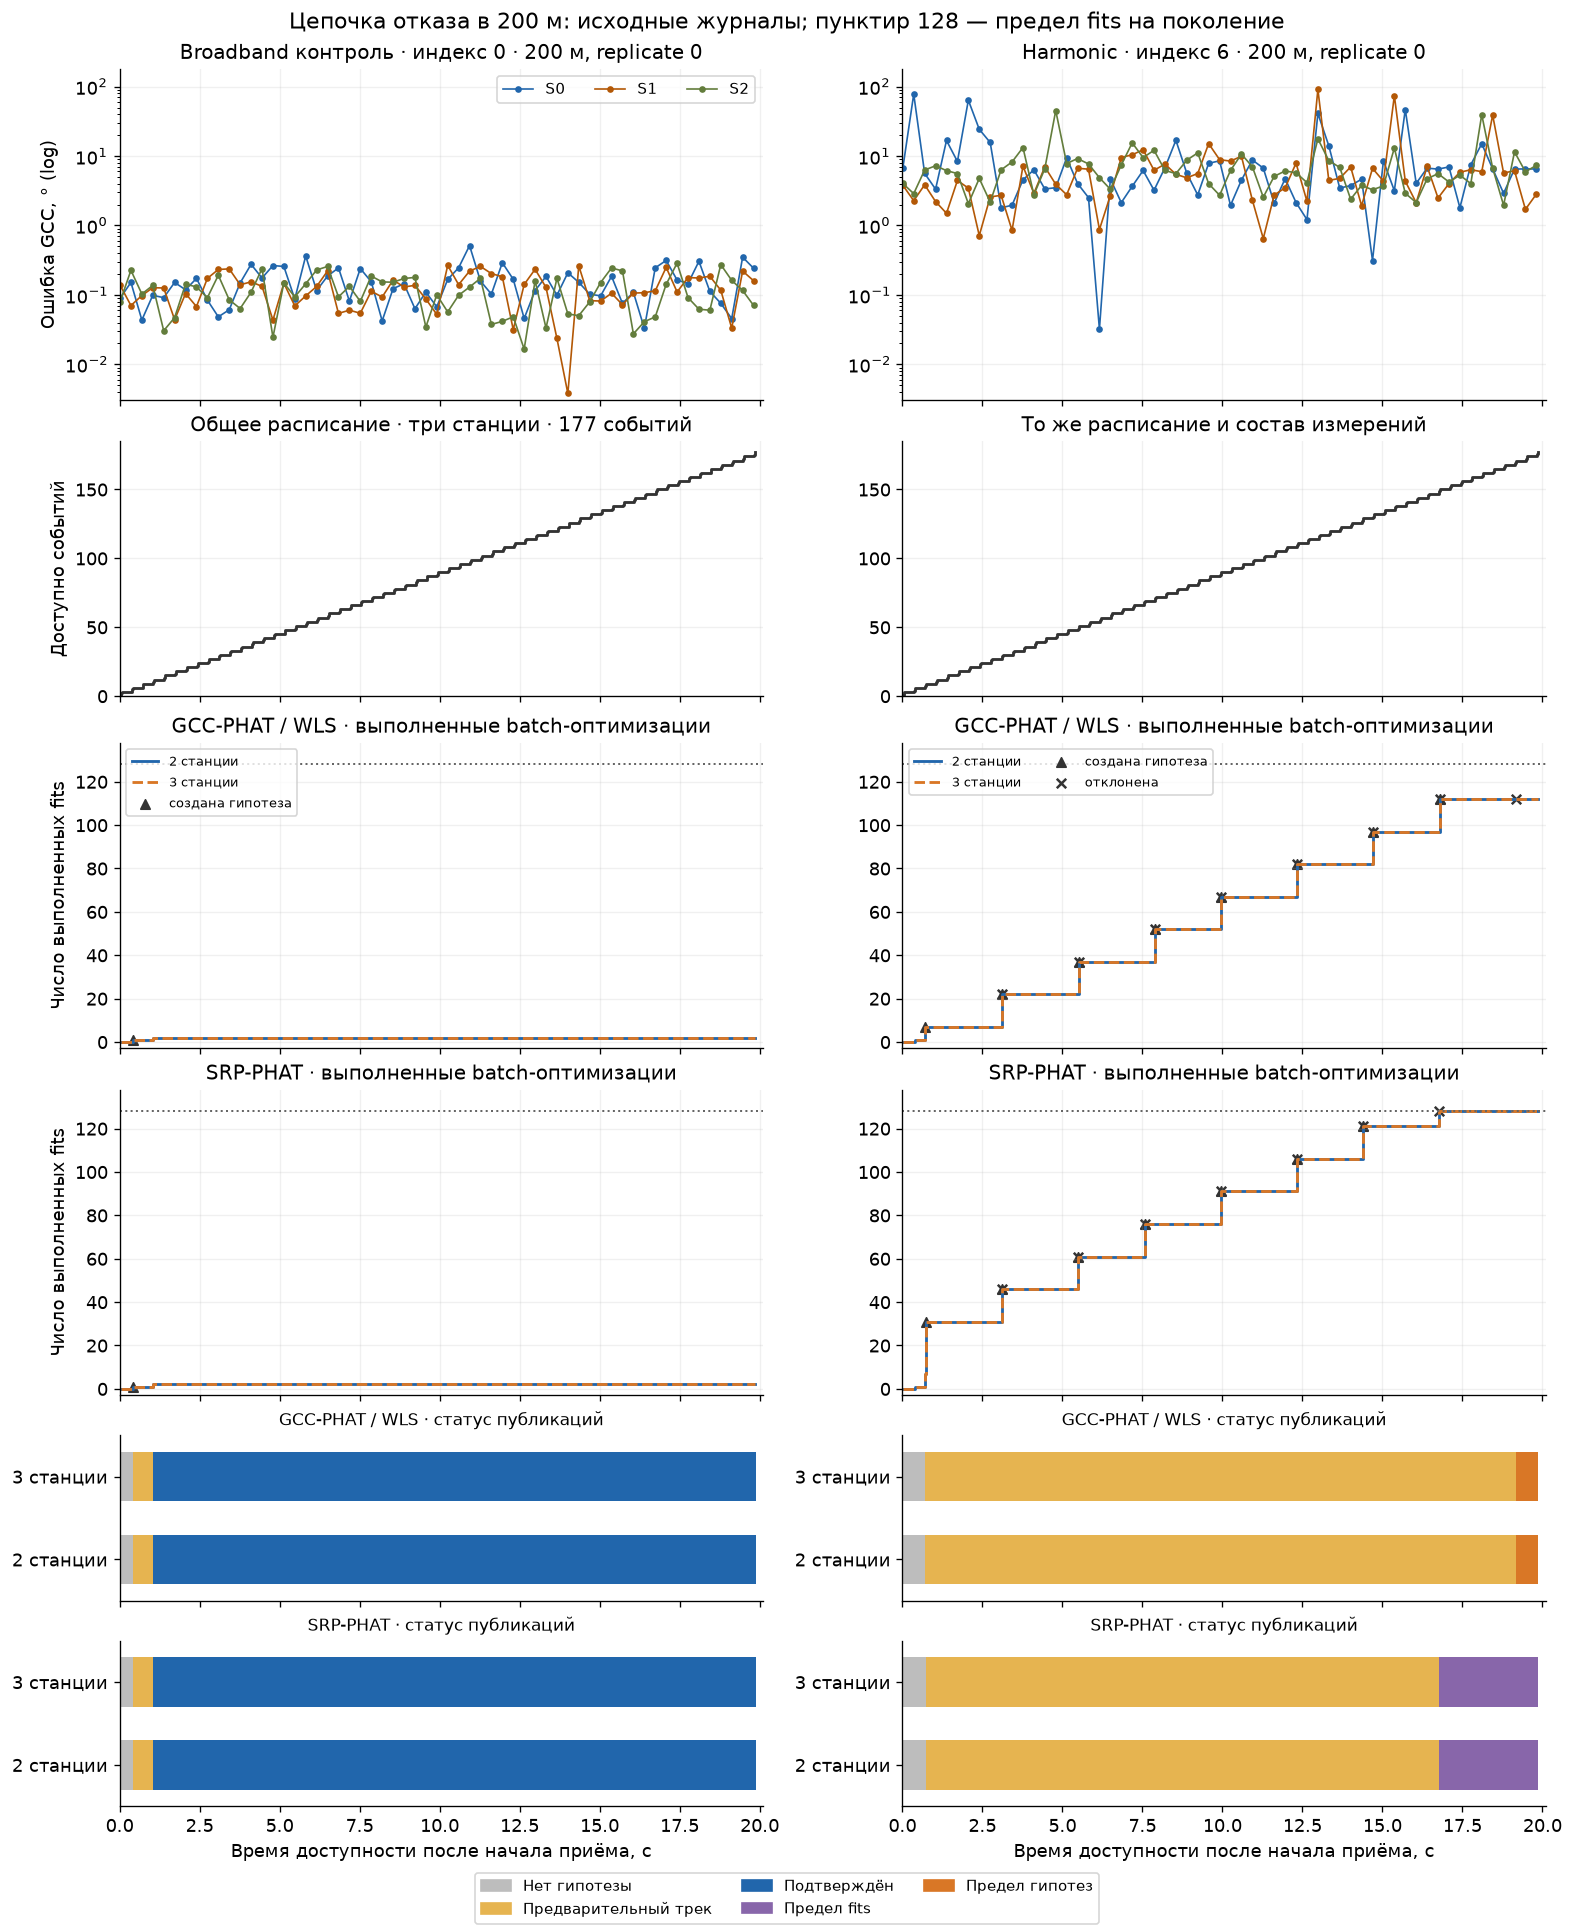

,method,hypothesis_index,processing_time_s,reason,predictive_S_count,predictive_S_passed_count,predictive_S_passed_station_count
93,all_6_equal_gcc_wls,1,3.118313,confirmation_inconsistent,22,2,1
95,all_6_equal_gcc_wls,2,5.507646,confirmation_inconsistent,21,1,1
97,all_6_equal_gcc_wls,3,7.881979,confirmation_inconsistent,20,0,0
99,all_6_equal_gcc_wls,4,9.959979,confirmation_inconsistent,20,0,0
101,all_6_equal_gcc_wls,5,12.334312,confirmation_inconsistent,20,0,0
103,all_6_equal_gcc_wls,6,14.708646,confirmation_inconsistent,20,0,0
105,all_6_equal_gcc_wls,7,16.786646,confirmation_inconsistent,20,0,0
107,all_6_equal_gcc_wls,8,19.160979,confirmation_inconsistent,20,0,0
123,equal_weight_srp_phat,1,3.118313,confirmation_inconsistent,20,0,0
125,equal_weight_srp_phat,2,5.492646,confirmation_inconsistent,20,0,0


In [7]:
display(chain[chain['index'].isin([0, 6])][['index', 'method', 'confirmation_variant',
    'available_event_count', 'created_hypothesis_count', 'executed_optimizations',
    'valid_publication_count', 'first_confirmation_s', 'hypothesis_limit_observed']])
fig = failure_timeline(timeline, hypotheses, residuals)
fig.savefig(FIGURES / 'failure_timeline_200m.png', bbox_inches='tight')
plt.show()
rejected = hypotheses[(hypotheses['index'] == 6) &
    (hypotheses.confirmation_variant == 'three_station_confirmation') &
    (hypotheses.action == 'tentative_rejected')]
display(rejected[['method', 'hypothesis_index', 'processing_time_s', 'reason',
    'predictive_S_count', 'predictive_S_passed_count', 'predictive_S_passed_station_count']])

## Контрфактический диагностический вход

Четыре replay выполнены до notebook, одним процессом одновременно, с внешними
дедлайнами 1800 с/7200 с. Notebook **только читает** результаты. Направления заново
рассчитаны при retarded emission time каждой станции; состав/validity/ID/reception/
availability и R прежние. Инициализатор получает только bearings, bias=0 и R;
истинные координаты ему не передаются. Успех не означает устранение манёвренных
ошибок сопровождения: при 700 м условная RMSE даже на идеальном входе около 7,23 м.

In [8]:
ledger = json.loads((OUT / 'ideal_replays/replay_ledger.json').read_text())
assert ledger['attempt_count'] == 4 and ledger['maximum_parallel_processes'] == 1
replays = []
for attempt in ledger['attempts']:
    directory = OUT / attempt['directory']
    summary = json.loads((directory / 'summary.json').read_text())
    for name, expected in summary['files_sha256'].items():
        assert sha256(directory / name) == expected
    assert summary['input_variant'] == 'ideal_bearing_zero_bias_same_R'
    assert attempt['status'] == summary['status'].replace('complete', 'completed')
    replays.append(summary)
display(pd.DataFrame(replays)[['index', 'method', 'publication_count', 'valid_publication_count',
    'first_confirmation_s', 'first_position_error_m', 'position_rmse_m_conditional',
    'executed_optimizations']].round(4))
print('Фактических replay:', ledger['attempt_count'], '; суммарное wall time, с:', round(ledger['total_wall_s'], 3))

,index,method,publication_count,valid_publication_count,first_confirmation_s,first_position_error_m,position_rmse_m_conditional,executed_optimizations
0,6,all_6_equal_gcc_wls,177,168,1.0553,0.1032,1.4399,2
1,6,equal_weight_srp_phat,177,168,1.0553,0.1032,1.4381,2
2,8,all_6_equal_gcc_wls,177,168,1.0553,0.6328,7.2321,2
3,8,equal_weight_srp_phat,177,168,1.0553,0.6329,7.2308,2


Фактических replay: 4 ; суммарное wall time, с: 14.753


## Выводы и следующий один шаг

1. **Установлено:** harmonic существенно ухудшает оба метода. Сохранённый флаг
   valid равен 100% у всех исследованных кадров и не распознаёт эти ошибки.
2. **Установлено:** прежние bias/R не описывают остатки harmonic как одно малое
   локальное гауссовское распределение. Для harmonic 200 м медиана станционных
   median $d_R^2$ порядка 507 GCC / 667 SRP; на 700 м ещё больше. Bias составляет
   около 0,01° и не сопоставим с ошибками нескольких/десятков градусов.
3. **Установлено:** в 200 м numerical batch acceptance не приводит к predictive
   подтверждению; в 700 м batch acceptance отсутствует. Идеальный вход проходит
   ту же цепочку с неизменными R и бюджетами. Отказ нельзя объяснить только
   техническим лимитом вычислений. Внешний исторический timeout потока 11 —
   отдельный механизм, не отказ этих пяти завершённых harmonic случаев.
4. **Следующая одна модификация:** проверяемый ambiguity/validity gate фронтенда
   на наблюдаемых данных. Он должен разрабатываться на отдельных source/noise
   seeds и затем проверяться на заранее отложенных независимых записях/движении;
   вместе измеряются доступность bearing, ошибки и confirmed availability.
   Этот notebook не задаёт его порог и не меняет рабочий алгоритм.

**Недостающее свидетельство:** исторический runner не экспортировал geometric
candidate rejection history, состояния/ковариации всех гипотез и каждое внутреннее
решение подтверждения. Кривые корреляции и выбранные pair-lag peaks не сохранены.
Поэтому происхождение больших направленных ошибок именно из ложных пиков остаётся
гипотезой. Новая R на evaluation не обучалась. S8 остаётся незавершённым.